In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR

c:\Users\Lenovo\miniconda3\envs\ocr-translate\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
c:\Users\Lenovo\miniconda3\envs\ocr-translate\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load image
# image_path = 'dataset_manga/train/images/0aMaCOpTaC_png.rf.8b26f3fc9d01ddeb1134765d32cb3bdc.jpg'
image_path=r"C:\Users\Lenovo\Downloads\manga2.png"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [3]:
# model=YOLO("yolov8m.pt")
ocr=PaddleOCR(
    use_gpu= False,
    lang='japan',
    det_algorithm='DB',
    rec_algorithm='SVTR_LCNet',
    use_angle_cls=True,
    drop_score=0.05,
    use_space_char=True,

    cls=True
    )

[2025/05/18 19:57:49] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\Lenovo/.paddleocr/whl\\det\\ml\\Multilingual_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\Lenovo/.paddleocr/whl\\rec\\japan\\japan_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_s

[2025/05/18 19:57:55] ppocr DEBUG: dt_boxes num : 6, elapsed : 0.5709860324859619
[2025/05/18 19:57:55] ppocr DEBUG: cls num  : 6, elapsed : 0.1619565486907959
[2025/05/18 19:57:56] ppocr DEBUG: rec_res num  : 6, elapsed : 0.5425276756286621


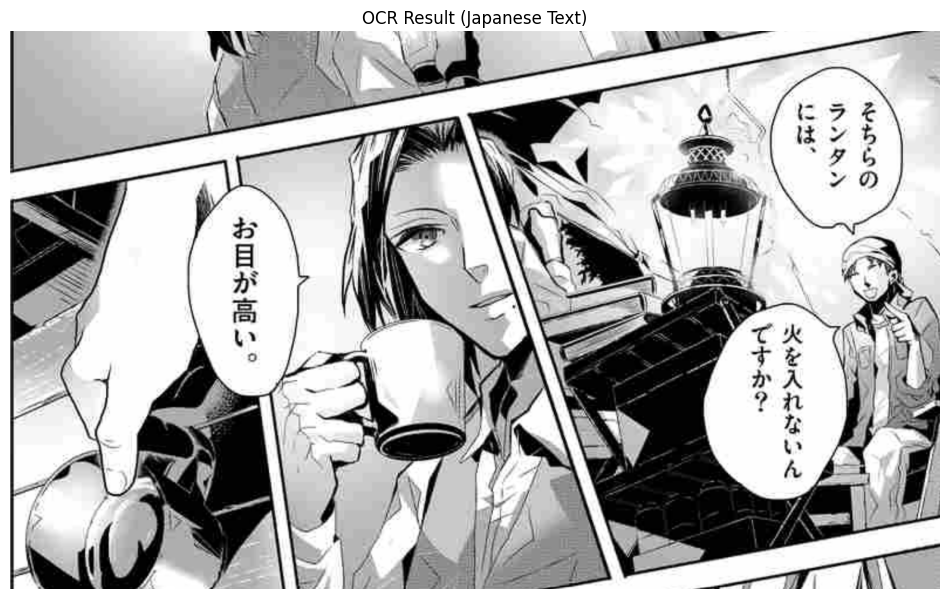


Recognized Japanese Text:
電ば (Confidence: 0.06)
nンスン (Confidence: 0.18)
モりの (Confidence: 0.53)
お目ガ高 (Confidence: 0.79)
Iなかo (Confidence: 0.14)
火屋北都ん (Confidence: 0.50)


In [4]:
# Run OCR
result = ocr.ocr(image_path, cls=True)

# Draw OCR results on image
for line in result:
    boxes = [item[0] for item in line]  # polygon box
    txts = [item[1][0] for item in line]  # text
    scores = [item[1][1] for item in line]  # confidence

# # # Visualize OCR results
# # image_with_boxes = draw_ocr(image_rgb, boxes, txts, scores, font_path='path/to/japanese/font.ttf')  # replace font if needed
# # image_with_boxes = cv2.cvtColor(image_with_boxes, cv2.COLOR_RGB2BGR)

# Display the image with OCR boxes and Japanese text
plt.figure(figsize=(12, 10))
plt.imshow(image)  # image_with_boxes is already in RGB format
plt.axis('off')  # Hide axis
plt.title("OCR Result (Japanese Text)")
plt.show()

# Print recognized text
print("\nRecognized Japanese Text:")
for line in result:
    for box, (text, conf) in line:
        print(f"{text} (Confidence: {conf:.2f})")

[2025/05/18 19:58:03] ppocr DEBUG: dt_boxes num : 6, elapsed : 0.2572615146636963
[2025/05/18 19:58:03] ppocr DEBUG: cls num  : 6, elapsed : 0.033179283142089844
[2025/05/18 19:58:03] ppocr DEBUG: rec_res num  : 6, elapsed : 0.34442925453186035


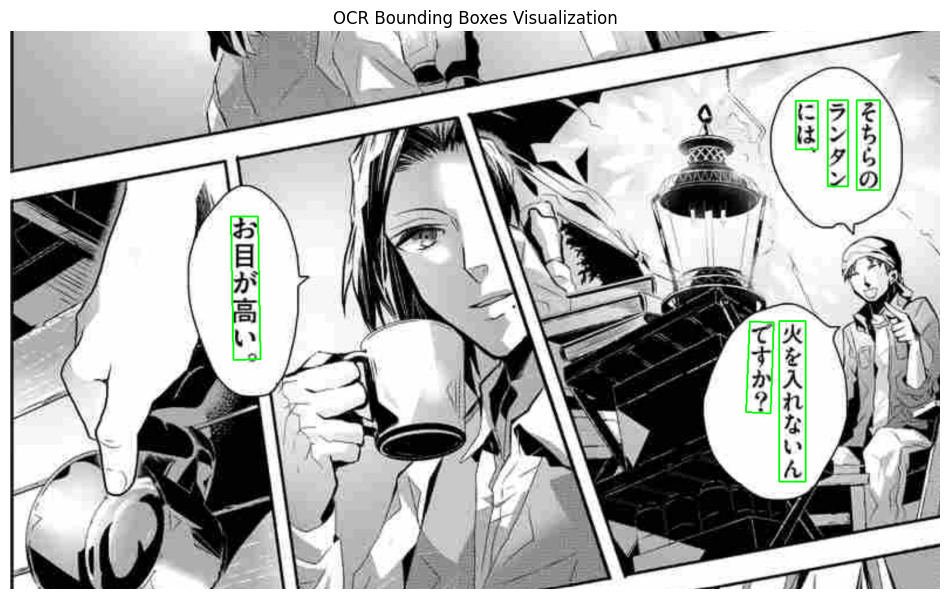


Recognized Japanese Text:
電ば (Confidence: 0.06)
nンスン (Confidence: 0.18)
モりの (Confidence: 0.53)
お目ガ高 (Confidence: 0.79)
Iなかo (Confidence: 0.14)
火屋北都ん (Confidence: 0.50)


In [5]:
import cv2
import matplotlib.pyplot as plt

# Assuming image is already loaded in BGR format via OpenCV
# If you have RGB image, convert to BGR for OpenCV drawing
image_bgr = cv2.imread(image_path)  # Original image in BGR

# Run OCR
result = ocr.ocr(image_path, cls=True)

# Draw bounding boxes on the image
for line in result:
    for box, (text, conf) in line:
        # box is list of 4 points, each point = [x, y]
        pts = box
        pts = [(int(x), int(y)) for x, y in pts]  # convert to int tuples

        # Draw polygon (bounding box) on the image (color green, thickness 2)
        cv2.polylines(image_bgr, [np.array(pts)], isClosed=True, color=(0, 255, 0), thickness=2)

# Convert BGR to RGB for display with matplotlib
image_rgb_with_boxes = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display the image with bounding boxes
plt.figure(figsize=(12, 10))
plt.imshow(image_rgb_with_boxes)
plt.axis('off')
plt.title("OCR Bounding Boxes Visualization")
plt.show()

# Print recognized text with confidence
print("\nRecognized Japanese Text:")
for line in result:
    for box, (text, conf) in line:
        print(f"{text} (Confidence: {conf:.2f})")


In [3]:
import cv2
from paddleocr import PaddleOCR

def improved_japanese_ocr_extraction(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    ocr = PaddleOCR(
        use_gpu=False,
        lang='japan',
        det_algorithm='DB',
        rec_algorithm='SVTR_LCNet',
        use_angle_cls=True,
        drop_score=0,
        use_space_char=True,
        cls=True
    )

    result = ocr.ocr(image_path, cls=True)

    lines = []
    for line in result:
        for box, (text, conf) in line:
            # Use the topmost y value for sorting
            y_min = min(pt[1] for pt in box)
            x_min = min(pt[0] for pt in box)
            lines.append((y_min, x_min, text, conf))

    # Sort by top-to-bottom, then left-to-right
    lines.sort(key=lambda x: (x[0], x[1]))

    # Join text with confidence filter
    sentence = ''.join([text for _, _, text, conf in lines if conf > 0.3])

    return sentence, lines

# Usage example
image_path = r"C:\Users\Lenovo\Downloads\manga2.png"
sentence, lines = improved_japanese_ocr_extraction(image_path)

print("Extracted Sentence:")
print(sentence)

print("\nDetailed lines:")
for y_min, x_min, text, conf in lines:
    print(f"Text: {text}, Confidence: {conf:.2f}")

[2025/05/17 12:30:03] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\Lenovo/.paddleocr/whl\\det\\ml\\Multilingual_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\Lenovo/.paddleocr/whl\\rec\\japan\\japan_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_s

[2025/05/17 13:25:49] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\Lenovo/.paddleocr/whl\\det\\ml\\Multilingual_PP-OCRv3_det_infer', det_limit_side_len=2400, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.4, det_db_unclip_ratio=1.8, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\Lenovo/.paddleocr/whl\\rec\\japan\\japan_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_

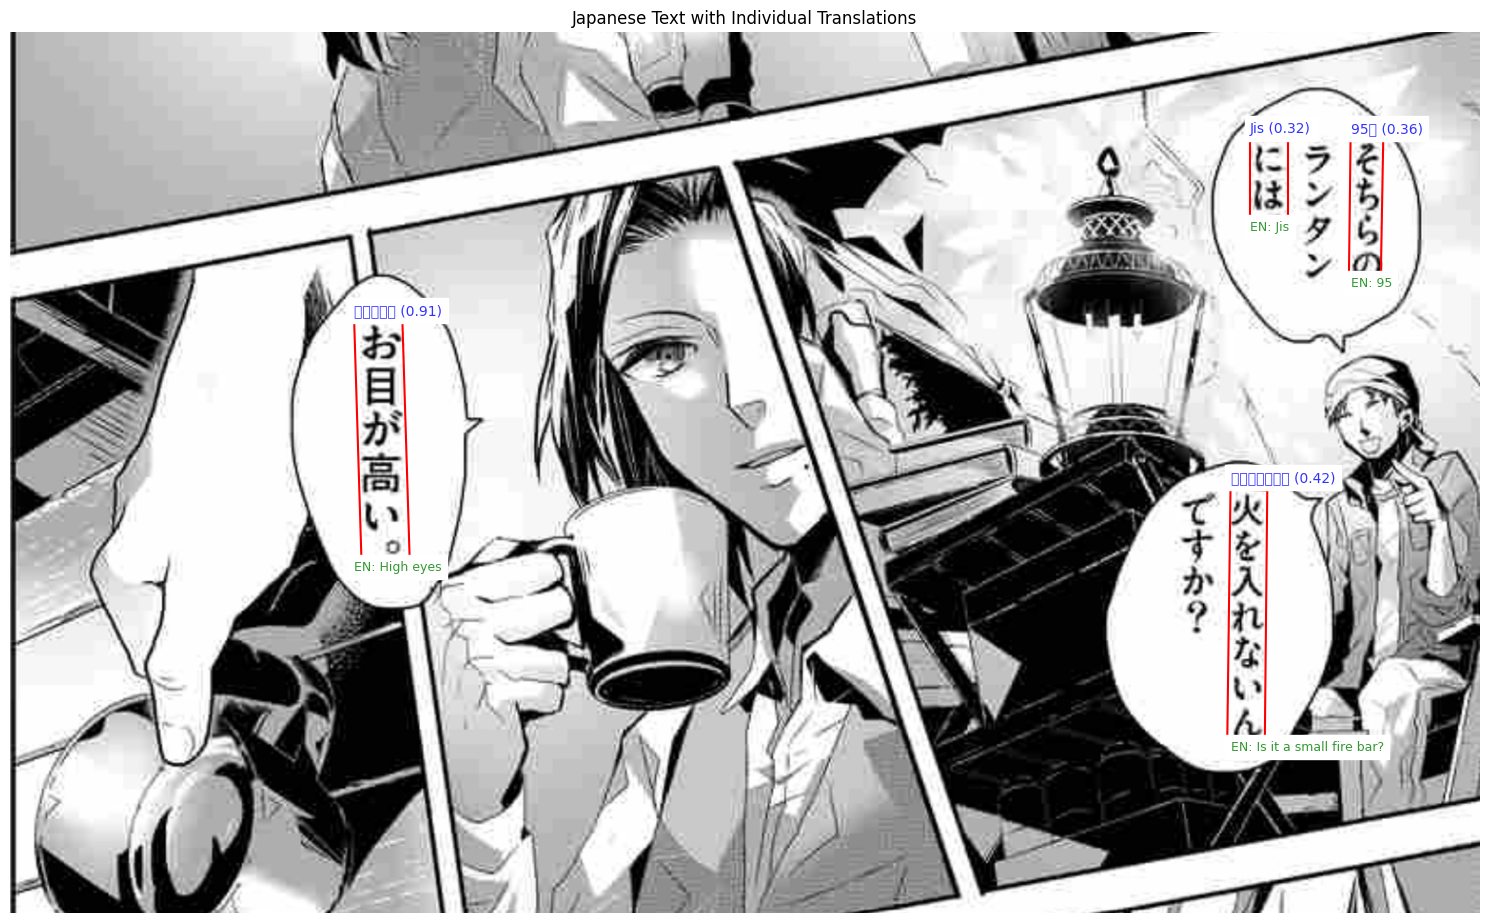


--- Individual Text and Translations ---
Japanese: Jis (Confidence: 0.32)
English: Jis
----------------------------------------
Japanese: 95た (Confidence: 0.36)
English: 95
----------------------------------------
Japanese: お目が高い (Confidence: 0.91)
English: High eyes
----------------------------------------
Japanese: 火産バルか小ん (Confidence: 0.42)
English: Is it a small fire bar?
----------------------------------------


In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from paddleocr import PaddleOCR
import matplotlib.patches as patches
from deep_translator import GoogleTranslator

def extract_japanese_text_with_individual_translations(image_path, visualization=True):
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    
    # Upscale image - Japanese characters benefit from higher resolution
    height, width = image.shape[:2]
    
    # Target width around 1600-2000px works well for Japanese OCR
    target_width = 1800
    scale_factor = target_width / width if width < target_width else 1.0
    
    # Only resize if original is too small
    if scale_factor > 1.0:
        image = cv2.resize(image, None, fx=scale_factor, fy=scale_factor, 
                          interpolation=cv2.INTER_CUBIC)
    
    # Image preprocessing
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Adaptive histogram equalization for better contrast
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    # Light denoising
    denoised = cv2.fastNlMeansDenoising(enhanced, h=10)
    
    # Convert back to RGB for visualization
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # PaddleOCR with fine-tuned parameters for Japanese text
    ocr = PaddleOCR(
        use_gpu=False,
        lang='japan',
        use_angle_cls=True,
        det_algorithm='DB',
        rec_algorithm='SVTR_LCNet',
        drop_score=0.01,
        use_space_char=True,
        det_db_thresh=0.3,
        det_db_box_thresh=0.4,
        det_db_unclip_ratio=1.8,
        det_limit_side_len=2400,
        det_db_score_mode="fast",
        rec_batch_num=6,
        ocr_version="PP-OCRv4"
    )
    
    # Run OCR on preprocessed image
    result = ocr.ocr(denoised, cls=True)
    
    # Process results with individual translations
    sorted_results = []
    translator = GoogleTranslator(source='ja', target='en')
    
    for line in result:
        for box, (text, conf) in line:
            if conf > 0.3:  # Only process high-confidence text
                y_min = min([p[1] for p in box])
                x_min = min([p[0] for p in box])
                
                # Translate each text individually
                try:
                    translation = translator.translate(text)
                except Exception as e:
                    translation = f"Translation error: {str(e)}"
                
                sorted_results.append((y_min, x_min, box, text, conf, translation))
    
    # Sort results by position
    sorted_results.sort()
    
    # Visualization
    if visualization and sorted_results:
        plt.figure(figsize=(15, 12))
        plt.imshow(image_rgb)
        ax = plt.gca()
        
        for _, _, box, text, score, translation in sorted_results:
            poly = patches.Polygon(box, closed=True, edgecolor='red', linewidth=1.5, facecolor='none')
            ax.add_patch(poly)
            
            # Position text labels
            x, y = box[0]
            # Original text (above box)
            ax.text(x, y - 10, f'{text} ({score:.2f})', fontsize=10, color='blue', 
                   backgroundcolor='white', alpha=0.8)
            # Translation (below box)
            ax.text(x, box[2][1] + 10, f'EN: {translation}', fontsize=9, color='green', 
                   backgroundcolor='white', alpha=0.8)
        
        plt.axis('off')
        plt.title("Japanese Text with Individual Translations")
        plt.tight_layout()
        plt.show()
    
    # Print results
    print("\n--- Individual Text and Translations ---")
    for _, _, _, text, conf, translation in sorted_results:
        print(f"Japanese: {text} (Confidence: {conf:.2f})")
        print(f"English: {translation}")
        print("-" * 40)
    
    return sorted_results

# Example usage

image_path = r"C:\Users\Lenovo\Downloads\manga2.png"
# image_path = 'WhatsApp Image 2025-05-17 at 11.04.40.jpeg'
results = extract_japanese_text_with_individual_translations(image_path)

In [6]:
pip install matplotlib 

   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.8 MB 3.4 MB/s eta 0:00:03
   -------- ------------------------------- 1.6/7.8 MB 4.7 MB/s eta 0:00:02
   ---------------- ----------------------- 3.1/7.8 MB 5.4 MB/s eta 0:00:01
   ------------------------- -------------- 5.0/7.8 MB 6.4 MB/s eta 0:00:01
   -------------------------------------- - 7.6/7.8 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 7.8/7.8 MB 7.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install deep_translator


Note: you may need to restart the kernel to use updated packages.
